# Device-resident policy decision pilot

## Result first

This experiment fixes the structural flaw in the earlier nested-graph
calibration. Both timed paths compute the same GPU predicate and execute the
same selected route body. The host path synchronizes and copies one 4-byte
decision at every epoch; the resident path keeps that decision on device and
tail-launches the selected uploaded graph.

The figures report every completed named placement. A placement, not a timing
row or validated invocation, is the sampling unit. This pilot reports effect
magnitudes and directions without a performance p-value.

## Frozen contract

- Source and hypotheses were frozen in
  `preregistration/resident-policy-001.md` after a disclosed tiny development
  smoke and before the full-grid placements.
- The host-only oracle shares neither predicate nor route functions with the
  CUDA implementation. Every invocation must match all state fields and the
  complete decision trace.
- Each measured row accumulates at least 100 ms of timed work. Reset, result
  copy, and exact validation remain outside timing, while the host predicate
  copy and synchronization remain inside the matched host path.
- `no_decision_lower_bound` has oracle route knowledge and is a structural
  floor, not a legal online scheduler.
- Reported P95/P99 diagnostics are quantiles across batch-average rows, not
  individual-invocation latency tails. The horizon monotonicity check is
  exploratory because the preregistration did not operationally define
  “advantage increases.”

In [1]:
from pathlib import Path
import json
import hashlib

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

cells = pd.read_csv(PROCESSED / "resident-policy-pilot-cell-summary.csv")
contrasts = pd.read_csv(PROCESSED / "resident-policy-pilot-contrasts.csv")
manifest = json.loads((PROCESSED / "resident-policy-pilot-manifest.json").read_text())

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

expected_outputs = {
    "cell_summary": PROCESSED / "resident-policy-pilot-cell-summary.csv",
    "contrasts": PROCESSED / "resident-policy-pilot-contrasts.csv",
}
for name, expected_path in expected_outputs.items():
    specification = manifest["outputs"][name]
    recorded_path = Path(specification["path"])
    if not recorded_path.is_absolute():
        recorded_path = ROOT / recorded_path
    assert recorded_path.resolve() == expected_path.resolve()
    assert int(specification["rows"]) == len(cells if name == "cell_summary" else contrasts)
    assert specification["sha256"] == sha256_file(expected_path)
sns.set_theme(style="ticks", context="paper", font_scale=1.08)

## Integrity and experimental grain

In [2]:
placement_count = contrasts["placement_id"].nunique()
assert placement_count == manifest["pilot_outcomes"]["placements"]
assert cells["placement_id"].nunique() == placement_count
assert manifest["quality_gates"]["all_placement_gates_pass"]
assert manifest["quality_gates"]["all_provider_bindings_pass"]
assert manifest["quality_gates"]["distinct_placement_ids"]
assert manifest["quality_gates"]["distinct_run_ids"]
assert (contrasts["technical_rows_paired"] == 30).all()

pd.DataFrame(
    {
        "quantity": [
            "named GPU placements",
            "measured rows",
            "validated invocations",
            "correctness failures",
            "performance p-values",
        ],
        "value": [
            placement_count,
            manifest["pilot_outcomes"]["raw_rows"],
            int(cells["validated_invocations"].sum()),
            0,
            0,
        ],
        "role": [
            "sampling units",
            "technical summaries",
            "deterministic validation work",
            "validity gate",
            "intentionally omitted at pilot n",
        ],
    }
)

,quantity,value,role
0,named GPU placements,4,sampling units
1,measured rows,3240,technical summaries
2,validated invocations,21974573,deterministic validation work
3,correctness failures,0,validity gate
4,performance p-values,0,intentionally omitted at pilot n


## Matched host round-trip versus resident decision

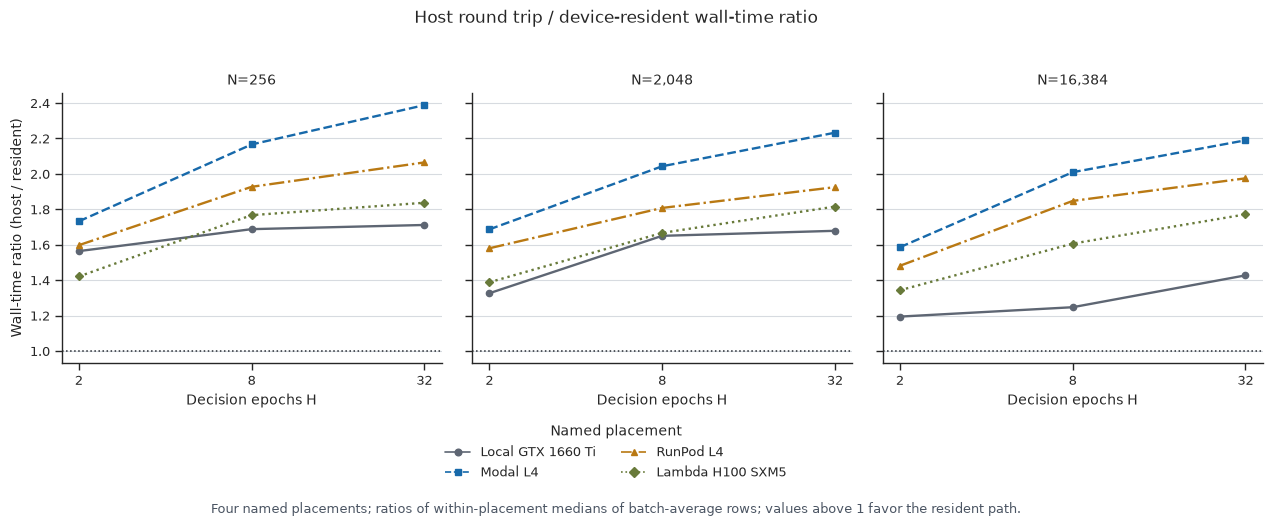

In [3]:
provider_labels = {
    "local": "Local GTX 1660 Ti",
    "modal": "Modal L4",
    "runpod": "RunPod L4",
    "lambda": "Lambda H100 SXM5",
}
provider_order = {"local": 0, "modal": 1, "runpod": 2, "lambda": 3}
provider_colors = {
    "local": "#5E6673",
    "modal": "#1769AA",
    "runpod": "#B97913",
    "lambda": "#687A3A",
}
provider_markers = {"local": "o", "modal": "s", "runpod": "^", "lambda": "D"}
provider_lines = {"local": "-", "modal": "--", "runpod": "-.", "lambda": ":"}
placement_meta = contrasts[
    ["placement_id", "provider", "device_name"]
].drop_duplicates()
labels = {
    placement: provider_labels[provider]
    for placement, provider, _ in placement_meta.itertuples(index=False, name=None)
}
placement_providers = {
    placement: provider
    for placement, provider, _ in placement_meta.itertuples(index=False, name=None)
}
placement_order = sorted(
    labels,
    key=lambda placement: provider_order[placement_providers[placement]],
)
plot_frame = contrasts.assign(
    placement_label=contrasts["placement_id"].map(labels),
    epochs_label=contrasts["epochs"].astype(str),
)
placement_palette = {
    labels[placement]: provider_colors[placement_providers[placement]]
    for placement in placement_order
}
placement_markers = {
    labels[placement]: provider_markers[placement_providers[placement]]
    for placement in placement_order
}
placement_lines = {
    labels[placement]: provider_lines[placement_providers[placement]]
    for placement in placement_order
}
agent_counts = sorted(plot_frame["agents"].unique())
fig, axes = plt.subplots(1, len(agent_counts), figsize=(13.2, 5.2), sharey=True)
for axis, agents in zip(axes, agent_counts, strict=True):
    panel = plot_frame[plot_frame["agents"].eq(agents)]
    for placement in [labels[item] for item in placement_order]:
        group = panel[panel["placement_label"].eq(placement)]
        group = group.sort_values("epochs")
        axis.plot(
            group["epochs_label"],
            group["host_over_resident_ratio_of_medians"],
            marker=placement_markers[placement],
            linestyle=placement_lines[placement],
            linewidth=1.7,
            markersize=4.5,
            color=placement_palette[placement],
        )
    axis.axhline(1.0, color="#262B33", linestyle=":", linewidth=1.1)
    axis.grid(axis="y", color="#D7DBE0", linewidth=0.8)
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
    axis.set_xlabel("Decision epochs H")
    axis.set_title(f"N={agents:,}")
axes[0].set_ylabel("Wall-time ratio (host / resident)")
fig.suptitle("Host round trip / device-resident wall-time ratio")
placement_handles = [
    Line2D(
        [0],
        [0],
        color=placement_palette[placement],
        marker=placement_markers[placement],
        linestyle=placement_lines[placement],
        label=placement,
    )
    for placement in [labels[item] for item in placement_order]
]
fig.legend(
    handles=placement_handles,
    frameon=False,
    title="Named placement",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.055),
    ncol=2,
    fontsize=9,
)
fig.text(
    0.5,
    0.012,
    "Four named placements; ratios of within-placement medians of batch-average rows; values above 1 favor the resident path.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.subplots_adjust(left=0.08, right=0.99, top=0.82, bottom=0.30, wspace=0.08)
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"resident-policy-speedup-by-horizon.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

## Frozen primary cell

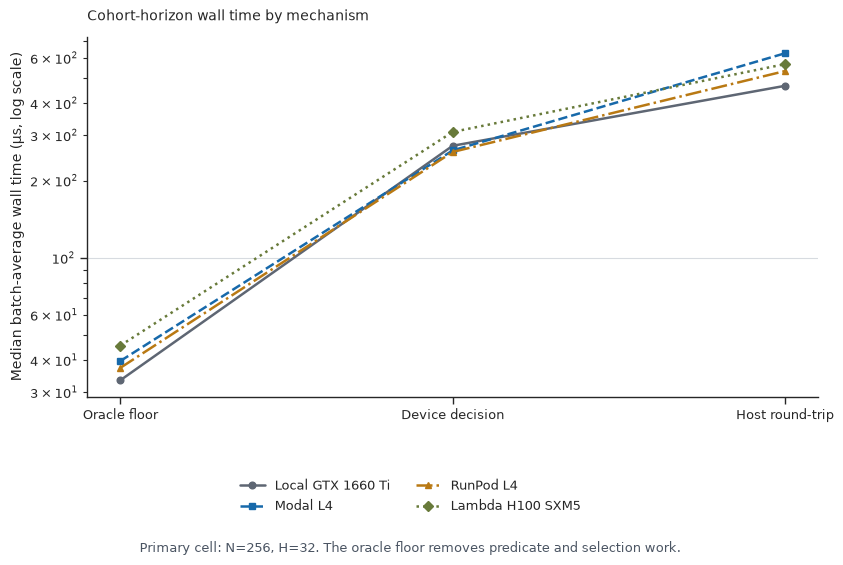

In [4]:
primary = cells[cells["agents"].eq(256) & cells["epochs"].eq(32)].copy()
mechanism_order = [
    "no_decision_lower_bound",
    "device_resident",
    "host_roundtrip",
]
mechanism_labels = {
    "no_decision_lower_bound": "Oracle floor",
    "device_resident": "Device decision",
    "host_roundtrip": "Host round-trip",
}
primary["mechanism_label"] = primary["mechanism"].map(mechanism_labels)
primary["placement_label"] = primary["placement_id"].map(labels)

fig, axis = plt.subplots(figsize=(8.5, 5.8))
for placement in [labels[item] for item in placement_order]:
    group = primary[primary["placement_label"].eq(placement)]
    group = group.set_index("mechanism").loc[mechanism_order].reset_index()
    axis.plot(
        group["mechanism_label"],
        group["wall_ns_median"] / 1_000,
        marker=placement_markers[placement],
        linestyle=placement_lines[placement],
        linewidth=1.8,
        label=placement,
        color=placement_palette[placement],
    )
axis.set_yscale("log")
axis.set_ylabel("Median batch-average wall time (µs, log scale)")
axis.set_xlabel("")
axis.set_title("Cohort-horizon wall time by mechanism", loc="left", pad=12)
axis.grid(axis="y", color="#D7DBE0", linewidth=0.8)
axis.grid(axis="x", visible=False)
sns.despine(ax=axis)
handles, legend_labels = axis.get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.06),
    ncol=2,
    fontsize=9,
)
fig.text(
    0.5,
    0.012,
    "Primary cell: N=256, H=32. The oracle floor removes predicate and selection work.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.subplots_adjust(left=0.12, right=0.98, top=0.90, bottom=0.28)
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"resident-policy-primary-mechanisms.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [5]:
primary_contrast = contrasts[
    contrasts["agents"].eq(256) & contrasts["epochs"].eq(32)
][
    [
        "placement_id",
        "provider",
        "device_name",
        "host_over_resident_ratio_of_medians",
        "resident_over_floor_ratio_of_medians",
        "wall_ns_saved_per_epoch",
    ]
]
primary_contrast.round(4)

,placement_id,provider,device_name,host_over_resident_ratio_of_medians,resident_over_floor_ratio_of_medians,wall_ns_saved_per_epoch
2,lambda-h100-3aa339b8e40349a8a1650d62ba26e709-1...,lambda,NVIDIA H100 80GB HBM3,1.8366,6.7774,8077.9169
11,local-gtx1660ti-rp001,local,NVIDIA GeForce GTX 1660 Ti,1.7111,8.1710,6067.1773
20,ta-01KZSCEECZ5ASAX5JQPGCJT1MR,modal,NVIDIA L4,2.3877,6.5963,11356.8088
29,td8sro1p62gj2c,runpod,NVIDIA L4,2.0642,6.9177,8591.5318


## Decision

This pilot advances only if the direction replicates on fresh cloud placements
with zero correctness failures. It does not authorize a broad systems claim.
The current batch-average timing cannot satisfy the planned P99 scale gate;
confirmation needs direct per-invocation or sampled-tail instrumentation.
Do not scale this microbenchmark directly. First harden raw-tail and CPU
measurement under a bounded qualification design; then add per-route
compaction, finite service, deadline-to-launch accounting, CPU fallback, and an
optimized legal baseline. Reserve nuisance-placement estimation and any
powered confirmation for the first online runtime that measures achievement
`A` relative to the exact offline opportunity `P*`.